# Tugas 10 | Word Graph

melakukan analisis teks berbasis graf untuk melihat hubungan antar kata dan menemukan kata-kata yang paling penting melalui co-occurrence graph dan PageRank


In [16]:
# ==========================
# 1. Install & Import
# ==========================
!pip install --upgrade pymupdf
!pip install nltk
!pip install networkx

import pymupdf
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Buka PDF dan ekstraksi teks → simpan ke output.txt

In [17]:
# ==========================
# 2. Extract text from jurnal.pdf
# ==========================

doc = pymupdf.open("jurnal.pdf")     # ganti ke file jurnal.pdf
out = open("output.txt", "wb")        # hasil teks

for page in doc:
    text = page.get_text().encode("utf8")
    out.write(text)
    out.write(bytes((12,)))           # page delimiter

out.close()

print("Ekstraksi PDF selesai!")


Ekstraksi PDF selesai!


## Code utama

Baca output.txt dan pecah menjadi kalimat

In [18]:
with open("output.txt", "r", encoding="utf-8") as file:
    teks = file.read()

sentences = nltk.sent_tokenize(teks)
print("Total kalimat:", len(sentences))

pd.DataFrame(sentences, columns=["kalimat"]).to_csv("kalimat.csv", index=False, encoding="utf-8")


Total kalimat: 829


**PREPROCESSING**

In [19]:
# ==========================
# 4. Preprocessing Teks (BERSIH & KETAT)
# ==========================

import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize

# Download resource tambahan
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Stopwords
stop_words = set(stopwords.words('english'))

# Noise khas PDF / LaTeX / Sitasi
PDF_NOISE = {
    'tex', 'latex', 'icecite', 'etal', 'fig', 'figure',
    'table', 'http', 'https', 'www', 'author', 'paper'
}

# --------------------------
# Helper Functions
# --------------------------

def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # hanya huruf
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def has_vowel(word):
    """Pastikan kata punya vokal"""
    return re.search(r'[aeiou]', word) is not None

def excessive_repetition(word, max_repeat=3):
    """Buang nnnnn, xxxxxx, dll"""
    return re.search(r'(.)\1{' + str(max_repeat) + ',}', word)

def is_english_word(word):
    """Cek kamus WordNet"""
    return bool(wordnet.synsets(word))

def filter_weird_words(words):
    filtered = []

    for w in words:

        # stopword
        if w in stop_words:
            continue

        # panjang kata wajar
        if len(w) < 3 or len(w) > 20:
            continue

        # hanya alfabet
        if not w.isalpha():
            continue

        # harus ada vokal
        if not has_vowel(w):
            continue

        # huruf berulang ekstrem
        if excessive_repetition(w):
            continue

        # noise PDF
        if w in PDF_NOISE:
            continue

        # pastikan kata Inggris
        if not is_english_word(w):
            continue

        filtered.append(w)

    return filtered

def preprocess_clean(text):
    text = clean_text_basic(text)
    words = word_tokenize(text)
    words = filter_weird_words(words)
    return words

# --------------------------
# Jalankan preprocessing
# --------------------------

clean_words = preprocess_clean(teks)
clean_text_joined = " ".join(clean_words)

# Simpan hasil
with open("preprocessed_clean.txt", "w", encoding="utf-8") as f:
    f.write(clean_text_joined)

# Statistik
from collections import Counter

print("Total kata setelah preprocessing:", len(clean_words))
print("Total kata unik:", len(set(clean_words)))

print("\n20 kata paling sering:")
print(Counter(clean_words).most_common(20))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\endyzan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Total kata setelah preprocessing: 7281
Total kata unik: 1124

20 kata paling sering:
[('text', 251), ('extraction', 118), ('semantic', 113), ('words', 93), ('evaluation', 85), ('benchmark', 80), ('word', 80), ('tools', 69), ('criteria', 60), ('characters', 59), ('document', 56), ('given', 53), ('order', 53), ('format', 50), ('see', 50), ('rule', 50), ('body', 48), ('information', 47), ('like', 47), ('paragraphs', 43)]


### eda

In [20]:

# 5.1 Jumlah kata
print("Jumlah kata:", len(clean_words))

# 5.2 Jumlah kata unik
print("Jumlah kata unik:", len(set(clean_words)))

# 5.3 20 kata paling sering
from collections import Counter
freq = Counter(clean_words)
print("\n20 kata paling sering muncul:")
print(freq.most_common(20))

# 5.4 Distribusi panjang kalimat
sentence_lengths = [len(s.split()) for s in sentences]
print("\nRata-rata panjang kalimat:", sum(sentence_lengths) / len(sentence_lengths))


Jumlah kata: 7281
Jumlah kata unik: 1124

20 kata paling sering muncul:
[('text', 251), ('extraction', 118), ('semantic', 113), ('words', 93), ('evaluation', 85), ('benchmark', 80), ('word', 80), ('tools', 69), ('criteria', 60), ('characters', 59), ('document', 56), ('given', 53), ('order', 53), ('format', 50), ('see', 50), ('rule', 50), ('body', 48), ('information', 47), ('like', 47), ('paragraphs', 43)]

Rata-rata panjang kalimat: 19.99276236429433


Buat Co-Occurrence Matrix dari teks

### co-occurrence matrix:
- Menggunakan jendela (window size = 2), kode menghitung seberapa sering dua kata muncul berdekatan.
- Tujuannya: menggambarkan hubungan antar kata dalam dokumen berdasarkan kedekatan munculnya.

In [21]:
window_size = 2
from collections import defaultdict, Counter

co_occ = defaultdict(Counter)

for i, word in enumerate(clean_words):
    for j in range(max(0, i - window_size), min(len(clean_words), i + window_size + 1)):
        if i != j:
            co_occ[word][clean_words[j]] += 1

unique_words = list(set(clean_words))
co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)
word_index = {word: idx for idx, word in enumerate(unique_words)}

for word, neighbors in co_occ.items():
    for neighbor, count in neighbors.items():
        co_matrix[word_index[word]][word_index[neighbor]] = count

co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)
co_matrix_df



,baseline,conference,single,consisting,explicitly,algorithms,exclusively,indexes,pitfalls,merges,...,measure,several,computes,marker,directly,layout,overview,found,tags,segmentation
baseline,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
conference,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
single,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
consisting,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
explicitly,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
layout,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
overview,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
found,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
tags,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Buat Graf Co-Occurrence

### Membangun graf co-occurrence & pagerank
- Matrix tersebut dikonversi menjadi sebuah graf (network) menggunakan networkx.
- Tujuannya: memvisualisasikan teks sebagai jaringan kata, sehingga struktur hubungan antar konsep dapat terlihat.

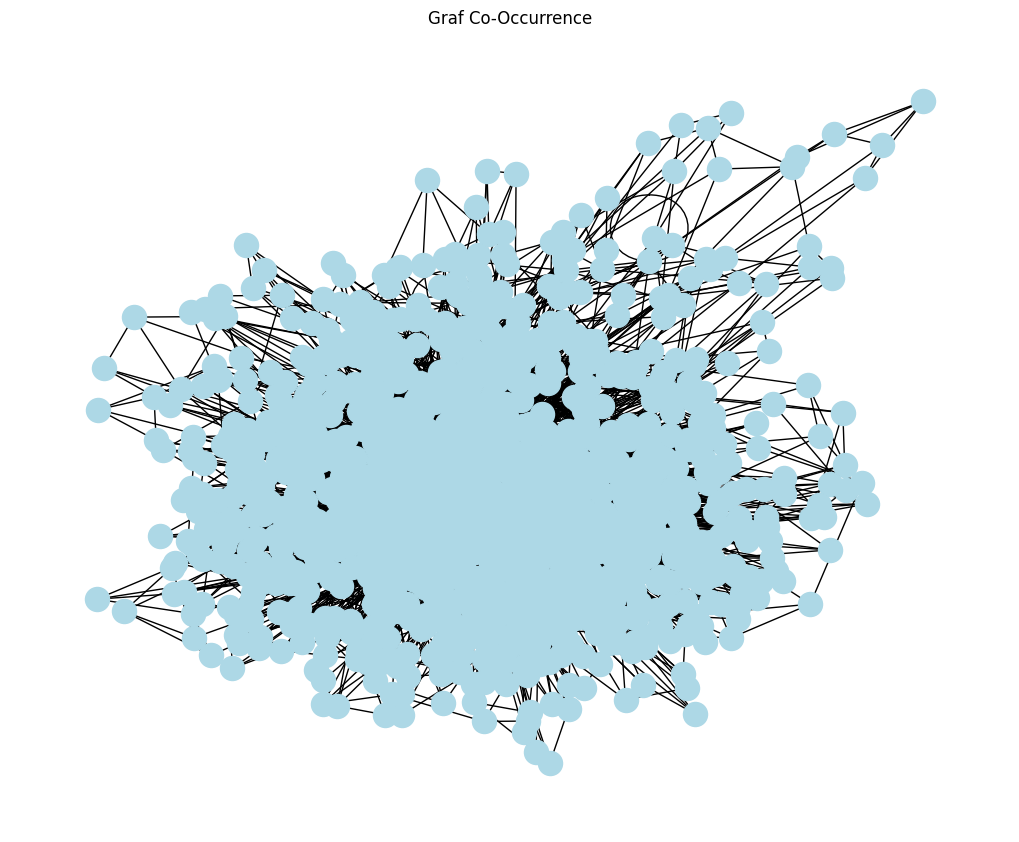


20 Kata Teratas berdasarkan PageRank:
            word  pagerank
415         text  0.025373
187   extraction  0.012837
824     semantic  0.010744
1017       words  0.010138
490   evaluation  0.009355
890         word  0.008259
543    benchmark  0.008167
165        tools  0.007838
203     criteria  0.007756
458        order  0.007288
708        given  0.006955
763         rule  0.006081
999   characters  0.005861
832          see  0.005855
684     articles  0.005752
875         like  0.005716
747     document  0.005427
319          les  0.005329
1112     command  0.005181
405      section  0.005093


In [22]:
G = nx.from_numpy_array(co_matrix_df.to_numpy())

plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=False, node_color='lightblue', node_size=300)
plt.title("Graf Co-Occurrence")
plt.show()

pagerank_scores = nx.pagerank(G)

pagerank_df = pd.DataFrame({
    "word": list(co_matrix_df.index),
    "pagerank": list(pagerank_scores.values())
}).sort_values(by="pagerank", ascending=False)

print("\n20 Kata Teratas berdasarkan PageRank:")
print(pagerank_df.head(20))

### Menghitung PageRank untuk mengidentifikasi kata paling penting
- menemukan kata yang paling sentral

- menentukan topik dominan dalam paper

- menganalisis kata yang paling mempengaruhi jaringan

PageRank berfungsi untuk menentukan kata mana yang paling penting / paling berpengaruh dalam dokumen berdasarkan koneksi antar kata.

Seberapa banyak sebuah kata dikunjungi oleh kata lain
Semakin sering suatu kata muncul berdekatan dengan banyak kata lain → semakin tinggi nilai PageRank-nya.

Seberapa penting kata-kata yang terhubung dengannya
Jika kata A muncul bersama kata B, dan kata B adalah kata penting, maka A ikut menjadi penting.

In [23]:
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G)
print("\nTotal komunitas:", len(communities))

for i, c in enumerate(communities):
    print(f"Komunitas {i+1}: {len(c)} kata")


Total komunitas: 13
Komunitas 1: 18 kata
Komunitas 2: 17 kata
Komunitas 3: 164 kata
Komunitas 4: 84 kata
Komunitas 5: 72 kata
Komunitas 6: 56 kata
Komunitas 7: 87 kata
Komunitas 8: 24 kata
Komunitas 9: 131 kata
Komunitas 10: 101 kata
Komunitas 11: 69 kata
Komunitas 12: 170 kata
Komunitas 13: 131 kata


**Komunitas**

In [24]:
word_list = list(co_matrix_df.index)
pagerank_dict = dict(zip(pagerank_df['word'], pagerank_df['pagerank']))

hasil_komunitas = []

for i, comm in enumerate(communities):
    comm_words = [word_list[node] for node in comm]
    pr_values = {w: pagerank_dict[w] for w in comm_words}
    top_word = max(pr_values, key=pr_values.get)

    hasil_komunitas.append({
        "komunitas": i+1,
        "jumlah_kata": len(comm_words),
        "kata_paling_dominan": top_word,
        "pagerank": pr_values[top_word]
    })

df_dominan = pd.DataFrame(hasil_komunitas)
df_dominan


,komunitas,jumlah_kata,kata_paling_dominan,pagerank
0,1,18,make,0.003023
1,2,17,digital,0.001988
2,3,164,articles,0.005752
3,4,84,text,0.025373
4,5,72,page,0.003640
5,6,56,learning,0.001286
6,7,87,tree,0.003942
7,8,24,line,0.004053
8,9,131,words,0.010138
9,10,101,criteria,0.007756


### EDA

In [25]:
print("Jumlah kalimat:", len(sentences))


Jumlah kalimat: 829


In [26]:
from nltk.tokenize import word_tokenize

words_all = word_tokenize(teks)      # teks = hasil preprocessing
print("Jumlah kata:", len(words_all))


Jumlah kata: 20315


In [27]:
unique_words = set(words_all)
print("Jumlah kata unik:", len(unique_words))


Jumlah kata unik: 2148


In [28]:
from collections import Counter

word_freq = Counter(words_all)
print("20 kata paling sering muncul:")
print(word_freq.most_common(20))

20 kata paling sering muncul:
[(',', 1004), ('the', 893), ('.', 825), ('of', 610), ('and', 418), ('(', 417), (')', 409), ('a', 383), ('is', 298), ('in', 282), ('to', 278), ('PDF', 229), ('for', 209), (':', 209), ('text', 195), ('from', 168), ('or', 166), ('are', 142), ('[', 133), (']', 133)]


In [29]:
sentence_lengths = [len(s.split()) for s in sentences]

print("Rata-rata panjang kalimat:", sum(sentence_lengths) / len(sentence_lengths))
print("Kalimat terpendek:", min(sentence_lengths), "kata")
print("Kalimat terpanjang:", max(sentence_lengths), "kata")


Rata-rata panjang kalimat: 19.99276236429433
Kalimat terpendek: 1 kata
Kalimat terpanjang: 390 kata


In [30]:
word_lengths = [len(w) for w in words_all]

print("Rata-rata panjang kata:", sum(word_lengths) / len(word_lengths))
print("Kata terpendek:", min(word_lengths))
print("Kata terpanjang:", max(word_lengths))


Rata-rata panjang kata: 4.099729264090573
Kata terpendek: 1
Kata terpanjang: 38
